In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("SBAcase.11.13.17.csv")

df_clean = df.copy()

print("Dimensão inicial da base:", df_clean.shape)
display(df_clean.head())

Dimensão inicial da base: (2102, 35)


,Selected,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession,daysterm,xx,Default
0,0,1004285007,SIMPLEX OFFICE SOLUTIONS,ANAHEIM,CA,92801,CALIFORNIA BANK & TRUST,CA,532420,15074,2001,36,1,1.0,0,0,1,0,Y,N,NaN,15095.0,32812,0,P I F,0,30000,15000,0,0,0.5,0,1080,16175.0,0
1,1,1004535010,DREAM HOME REALTY,TORRANCE,CA,90505,CALIFORNIA BANK & TRUST,CA,531210,15130,2001,56,1,1.0,0,0,1,0,Y,N,NaN,15978.0,30000,0,P I F,0,30000,15000,0,0,0.5,1,1680,17658.0,0
2,0,1005005006,"Winset, Inc. dba Bankers Hill",SAN DIEGO,CA,92103,CALIFORNIA BANK & TRUST,CA,531210,15188,2001,36,10,1.0,0,0,1,0,Y,N,NaN,15218.0,30000,0,P I F,0,30000,15000,0,0,0.5,0,1080,16298.0,0
3,1,1005535001,Shiva Management,SAN DIEGO,CA,92108,CALIFORNIA BANK & TRUST,CA,531312,15719,2003,36,6,1.0,0,0,1,0,Y,N,NaN,15736.0,50000,0,P I F,0,50000,25000,0,0,0.5,0,1080,16816.0,0
4,1,1005996006,"GOLD CROWN HOME LOANS, INC",LOS ANGELES,CA,91345,SBA - EDF ENFORCEMENT ACTION,CO,531390,16840,2006,240,65,1.0,3,65,1,1,0,N,NaN,16903.0,343000,0,P I F,0,343000,343000,0,1,1.0,0,7200,24103.0,0


In [2]:
print("Informações gerais:")
display(df_clean.info())

print("\nValores nulos por coluna:")
display(df_clean.isnull().sum().sort_values(ascending=False))

print("\nDuplicatas:")
print("Linhas duplicadas:", df_clean.duplicated().sum())
print("Empréstimos duplicados:", df_clean["LoanNr_ChkDgt"].duplicated().sum())

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2102 entries, 0 to 2101
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Selected           2102 non-null   int64  
 1   LoanNr_ChkDgt      2102 non-null   int64  
 2   Name               2102 non-null   object 
 3   City               2102 non-null   object 
 4   State              2102 non-null   object 
 5   Zip                2102 non-null   int64  
 6   Bank               2099 non-null   object 
 7   BankState          2099 non-null   object 
 8   NAICS              2102 non-null   int64  
 9   ApprovalDate       2102 non-null   int64  
 10  ApprovalFY         2102 non-null   int64  
 11  Term               2102 non-null   int64  
 12  NoEmp              2102 non-null   int64  
 13  NewExist           2101 non-null   float64
 14  CreateJob          2102 non-null   int64  
 15  RetainedJob        2102 non-null   int64  
 16  Fran

None


Valores nulos por coluna:


ChgOffDate           1405
Bank                    3
LowDoc                  3
xx                      3
DisbursementDate        3
BankState               3
RevLineCr               2
NewExist                1
Name                    0
Selected                0
LoanNr_ChkDgt           0
ApprovalFY              0
ApprovalDate            0
NoEmp                   0
Term                    0
Zip                     0
NAICS                   0
State                   0
City                    0
UrbanRural              0
FranchiseCode           0
RetainedJob             0
CreateJob               0
BalanceGross            0
MIS_Status              0
ChgOffPrinGr            0
DisbursementGross       0
GrAppv                  0
SBA_Appv                0
RealEstate              0
New                     0
Portion                 0
Recession               0
daysterm                0
Default                 0
dtype: int64


Duplicatas:
Linhas duplicadas: 0
Empréstimos duplicados: 0


In [3]:
#CONVERSÃO DAS DATAS
date_cols = ["ApprovalDate", "DisbursementDate", "ChgOffDate", "xx"]

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], origin="1960-01-01", unit="D", errors="coerce")

display(df_clean[date_cols].head())

,ApprovalDate,DisbursementDate,ChgOffDate,xx
0,2001-04-09,2001-04-30,NaT,2004-04-14
1,2001-06-04,2003-09-30,NaT,2008-05-06
2,2001-08-01,2001-08-31,NaT,2004-08-15
3,2003-01-14,2003-01-31,NaT,2006-01-15
4,2006-02-08,2006-04-12,NaT,2025-12-28


In [4]:
#PADRONIZAÇÃO DAS VARIÁVEIS CATEGÓRICAS 

df_clean["RevLineCr"] = df_clean["RevLineCr"].replace({
    "Y": "Y",
    "N": "N",
    "0": np.nan,
    "T": np.nan
})

df_clean["LowDoc"] = df_clean["LowDoc"].replace({
    "Y": "Y",
    "N": "N",
    "0": np.nan,
    "S": np.nan,
    "A": np.nan
})

print("Categorias após padronização:")
print("\nRevLineCr:")
display(df_clean["RevLineCr"].value_counts(dropna=False))

print("\nLowDoc:")
display(df_clean["LowDoc"].value_counts(dropna=False))

Categorias após padronização:

RevLineCr:


RevLineCr
NaN    785
Y      737
N      580
Name: count, dtype: int64


LowDoc:


LowDoc
N      2053
Y        41
NaN       8
Name: count, dtype: int64

In [5]:
df_clean["NewExist"] = df_clean["NewExist"].replace(0, np.nan)

print("Distribuição de NewExist após correção:")
display(df_clean["NewExist"].value_counts(dropna=False))

Distribuição de NewExist após correção:


NewExist
1.0    1776
2.0     324
NaN       2
Name: count, dtype: int64

In [6]:
#LIMPEZA DE COLUNAS MONETÁRIAS
money_cols = ["DisbursementGross", "BalanceGross", "ChgOffPrinGr", "GrAppv", "SBA_Appv"]

for col in money_cols:
    if df_clean[col].dtype == "object":
        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip()
        )
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("Tipos após limpeza monetária:")
display(df_clean[money_cols].dtypes)

Tipos após limpeza monetária:


DisbursementGross    int64
BalanceGross         int64
ChgOffPrinGr         int64
GrAppv               int64
SBA_Appv             int64
dtype: object

In [7]:
if (df_clean["BalanceGross"] == 0).all():
    df_clean = df_clean.drop(columns=["BalanceGross"])
    print("Coluna 'BalanceGross' removida.")
else:
    print("Coluna 'BalanceGross' mantida.")

Coluna 'BalanceGross' removida.


In [8]:
#RECODIFICAÇÃO DE VARIÁVEIS PARA FACILITAR A ANÁLISE

df_clean["MIS_Status_Label"] = df_clean["MIS_Status"].replace({
    "P I F": "Paid in Full",
    "CHGOFF": "Charged Off"
})

df_clean["Default_Label"] = df_clean["Default"].replace({
    0: "No Default",
    1: "Default"
})

df_clean["Business_Type"] = df_clean["NewExist"].replace({
    1: "Existing Business",
    2: "New Business"
})

df_clean["UrbanRural_Label"] = df_clean["UrbanRural"].replace({
    0: "Undefined",
    1: "Urban",
    2: "Rural"
})

df_clean["RevLineCr_Label"] = df_clean["RevLineCr"].replace({
    "Y": "Yes",
    "N": "No"
})

df_clean["LowDoc_Label"] = df_clean["LowDoc"].replace({
    "Y": "Yes",
    "N": "No"
})

df_clean["Recession_Label"] = df_clean["Recession"].replace({
    0: "No",
    1: "Yes"
})

display(df_clean[[
    "MIS_Status", "MIS_Status_Label",
    "Default", "Default_Label",
    "NewExist", "Business_Type",
    "UrbanRural", "UrbanRural_Label"
]].head())

,MIS_Status,MIS_Status_Label,Default,Default_Label,NewExist,Business_Type,UrbanRural,UrbanRural_Label
0,P I F,Paid in Full,0,No Default,1.0,Existing Business,0,Undefined
1,P I F,Paid in Full,0,No Default,1.0,Existing Business,0,Undefined
2,P I F,Paid in Full,0,No Default,1.0,Existing Business,0,Undefined
3,P I F,Paid in Full,0,No Default,1.0,Existing Business,0,Undefined
4,P I F,Paid in Full,0,No Default,1.0,Existing Business,1,Urban


In [9]:
#EXTRAÇÃO DO SETOR A PARTIR DO NAICS

df_clean["NAICS"] = df_clean["NAICS"].astype(str).str[:2]

naics_map = {
    "11": "Agriculture, Forestry, Fishing and Hunting",
    "21": "Mining, Quarrying, and Oil and Gas Extraction",
    "22": "Utilities",
    "23": "Construction",
    "31": "Manufacturing",
    "32": "Manufacturing",
    "33": "Manufacturing",
    "42": "Wholesale Trade",
    "44": "Retail Trade",
    "45": "Retail Trade",
    "48": "Transportation and Warehousing",
    "49": "Transportation and Warehousing",
    "51": "Information",
    "52": "Finance and Insurance",
    "53": "Real Estate and Rental and Leasing",
    "54": "Professional, Scientific, and Technical Services",
    "55": "Management of Companies and Enterprises",
    "56": "Administrative and Support Services",
    "61": "Educational Services",
    "62": "Health Care and Social Assistance",
    "71": "Arts, Entertainment, and Recreation",
    "72": "Accommodation and Food Services",
    "81": "Other Services (except Public Administration)",
    "92": "Public Administration"
}

df_clean["Sector"] = df_clean["NAICS"].map(naics_map)
df_clean["Sector"] = df_clean["Sector"].fillna("Unknown")

print("Top setores:")
display(df_clean["Sector"].value_counts().head(10))

Top setores:


Sector
Real Estate and Rental and Leasing    2102
Name: count, dtype: int64

In [10]:
#CRIAÇÃO DE FAIXAS PARA ANÁLISE

df_clean["Disbursement_Faixa"] = pd.qcut(
    df_clean["DisbursementGross"],
    q=4,
    labels=["Baixo", "Médio-Baixo", "Médio-Alto", "Alto"],
    duplicates="drop"
)

df_clean["Term_Faixa"] = pd.cut(
    df_clean["Term"],
    bins=[0, 60, 120, 180, 240, np.inf],
    labels=["Até 5 anos", "5-10 anos", "10-15 anos", "15-20 anos", "Acima de 20 anos"]
)

df_clean["NoEmp_Faixa"] = pd.cut(
    df_clean["NoEmp"],
    bins=[-1, 5, 20, 100, np.inf],
    labels=["Micro", "Pequena", "Média", "Grande"]
)

display(df_clean[["DisbursementGross", "Disbursement_Faixa", "Term", "Term_Faixa", "NoEmp", "NoEmp_Faixa"]].head())

,DisbursementGross,Disbursement_Faixa,Term,Term_Faixa,NoEmp,NoEmp_Faixa
0,32812,Baixo,36,Até 5 anos,1,Micro
1,30000,Baixo,56,Até 5 anos,1,Micro
2,30000,Baixo,36,Até 5 anos,10,Pequena
3,50000,Médio-Baixo,36,Até 5 anos,6,Pequena
4,343000,Alto,240,15-20 anos,65,Média


In [11]:
#TRATAMENTO DE NULOS

cat_fill_unknown = ["Bank", "BankState", "RevLineCr", "LowDoc"]

for col in cat_fill_unknown:
    df_clean[col] = df_clean[col].fillna("Unknown")

df_clean["RevLineCr_Label"] = df_clean["RevLineCr_Label"].fillna("Unknown")
df_clean["LowDoc_Label"] = df_clean["LowDoc_Label"].fillna("Unknown")
df_clean["Business_Type"] = df_clean["Business_Type"].fillna("Unknown")

df_clean = df_clean.dropna(subset=["ApprovalDate", "DisbursementDate"])

print("Dimensão após tratamento de nulos:", df_clean.shape)

print("\nNulos restantes:")
display(df_clean.isnull().sum().sort_values(ascending=False).head(15))

Dimensão após tratamento de nulos: (2099, 45)

Nulos restantes:


ChgOffDate       1402
Term_Faixa          3
NewExist            2
LoanNr_ChkDgt       0
Selected            0
Zip                 0
Bank                0
BankState           0
NAICS               0
ApprovalDate        0
Name                0
City                0
State               0
NoEmp               0
Term                0
dtype: int64

In [12]:
#VERIFICAÇÃO DE CONSISTÊNCIA

consistencia = ((df_clean["MIS_Status"] == "CHGOFF") & (df_clean["Default"] == 1)) | \
               ((df_clean["MIS_Status"] == "P I F") & (df_clean["Default"] == 0))

print("Percentual de consistência entre MIS_Status e Default:")
print(f"{consistencia.mean() * 100:.2f}%")

print("\nDuplicatas após limpeza:")
print("Linhas duplicadas:", df_clean.duplicated().sum())
print("Empréstimos duplicados:", df_clean["LoanNr_ChkDgt"].duplicated().sum())

Percentual de consistência entre MIS_Status e Default:
100.00%

Duplicatas após limpeza:
Linhas duplicadas: 0
Empréstimos duplicados: 0


In [13]:
#COLUNAS QUE DEVEM SER EVITADAS NA MODELAGEM

leakage_cols = [
    "MIS_Status",
    "MIS_Status_Label",
    "ChgOffDate",
    "ChgOffPrinGr",
    "xx"
]

print("Colunas com potencial vazamento de informação:")
print(leakage_cols)

Colunas com potencial vazamento de informação:
['MIS_Status', 'MIS_Status_Label', 'ChgOffDate', 'ChgOffPrinGr', 'xx']


In [14]:
print("Dimensão final da base limpa:", df_clean.shape)

print("\nTipos de dados:")
display(df_clean.dtypes)

print("\nValores nulos finais:")
display(df_clean.isnull().sum().sort_values(ascending=False).head(20))

print("\nAmostra final:")
display(df_clean.head())

Dimensão final da base limpa: (2099, 45)

Tipos de dados:


Selected                       int64
LoanNr_ChkDgt                  int64
Name                          object
City                          object
State                         object
Zip                            int64
Bank                          object
BankState                     object
NAICS                         object
ApprovalDate          datetime64[ns]
ApprovalFY                     int64
Term                           int64
NoEmp                          int64
NewExist                     float64
CreateJob                      int64
RetainedJob                    int64
FranchiseCode                  int64
UrbanRural                     int64
RevLineCr                     object
LowDoc                        object
ChgOffDate            datetime64[ns]
DisbursementDate      datetime64[ns]
DisbursementGross              int64
MIS_Status                    object
ChgOffPrinGr                   int64
GrAppv                         int64
SBA_Appv                       int64
N


Valores nulos finais:


ChgOffDate       1402
Term_Faixa          3
NewExist            2
LoanNr_ChkDgt       0
Selected            0
Zip                 0
Bank                0
BankState           0
NAICS               0
ApprovalDate        0
Name                0
City                0
State               0
NoEmp               0
Term                0
ApprovalFY          0
RetainedJob         0
FranchiseCode       0
UrbanRural          0
RevLineCr           0
dtype: int64


Amostra final:


,Selected,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession,daysterm,xx,Default,MIS_Status_Label,Default_Label,Business_Type,UrbanRural_Label,RevLineCr_Label,LowDoc_Label,Recession_Label,Sector,Disbursement_Faixa,Term_Faixa,NoEmp_Faixa
0,0,1004285007,SIMPLEX OFFICE SOLUTIONS,ANAHEIM,CA,92801,CALIFORNIA BANK & TRUST,CA,53,2001-04-09,2001,36,1,1.0,0,0,1,0,Y,N,NaT,2001-04-30,32812,P I F,0,30000,15000,0,0,0.5,0,1080,2004-04-14,0,Paid in Full,No Default,Existing Business,Undefined,Yes,No,No,Real Estate and Rental and Leasing,Baixo,Até 5 anos,Micro
1,1,1004535010,DREAM HOME REALTY,TORRANCE,CA,90505,CALIFORNIA BANK & TRUST,CA,53,2001-06-04,2001,56,1,1.0,0,0,1,0,Y,N,NaT,2003-09-30,30000,P I F,0,30000,15000,0,0,0.5,1,1680,2008-05-06,0,Paid in Full,No Default,Existing Business,Undefined,Yes,No,Yes,Real Estate and Rental and Leasing,Baixo,Até 5 anos,Micro
2,0,1005005006,"Winset, Inc. dba Bankers Hill",SAN DIEGO,CA,92103,CALIFORNIA BANK & TRUST,CA,53,2001-08-01,2001,36,10,1.0,0,0,1,0,Y,N,NaT,2001-08-31,30000,P I F,0,30000,15000,0,0,0.5,0,1080,2004-08-15,0,Paid in Full,No Default,Existing Business,Undefined,Yes,No,No,Real Estate and Rental and Leasing,Baixo,Até 5 anos,Pequena
3,1,1005535001,Shiva Management,SAN DIEGO,CA,92108,CALIFORNIA BANK & TRUST,CA,53,2003-01-14,2003,36,6,1.0,0,0,1,0,Y,N,NaT,2003-01-31,50000,P I F,0,50000,25000,0,0,0.5,0,1080,2006-01-15,0,Paid in Full,No Default,Existing Business,Undefined,Yes,No,No,Real Estate and Rental and Leasing,Médio-Baixo,Até 5 anos,Pequena
4,1,1005996006,"GOLD CROWN HOME LOANS, INC",LOS ANGELES,CA,91345,SBA - EDF ENFORCEMENT ACTION,CO,53,2006-02-08,2006,240,65,1.0,3,65,1,1,Unknown,N,NaT,2006-04-12,343000,P I F,0,343000,343000,0,1,1.0,0,7200,2025-12-28,0,Paid in Full,No Default,Existing Business,Urban,Unknown,No,No,Real Estate and Rental and Leasing,Alto,15-20 anos,Média


In [15]:
df_clean.to_csv("SBAcase_clean.csv", index=False)
print("Base limpa salva como: SBAcase_clean.csv")

Base limpa salva como: SBAcase_clean.csv


In [16]:
print("Dimensão da base limpa:", df_clean.shape)

default_rate = df_clean["Default"].mean() * 100
paid_rate = 100 - default_rate

print(f"Taxa de inadimplência: {default_rate:.2f}%")
print(f"Taxa de adimplência: {paid_rate:.2f}%")

display(df_clean[["DisbursementGross", "Term", "NoEmp", "Portion"]].describe())

Dimensão da base limpa: (2099, 45)
Taxa de inadimplência: 32.68%
Taxa de adimplência: 67.32%


,DisbursementGross,Term,NoEmp,Portion
count,2.099000e+03,2099.000000,2099.000000,2099.000000
mean,2.430127e+05,127.087661,10.156741,0.671299
std,3.384465e+05,93.816261,34.426110,0.186540
min,4.835000e+03,0.000000,0.000000,0.296770
25%,4.004350e+04,60.000000,2.000000,0.500000
50%,1.000000e+05,84.000000,3.000000,0.506439
75%,3.000000e+05,240.000000,8.000000,0.850000
max,2.315000e+06,306.000000,650.000000,1.000000


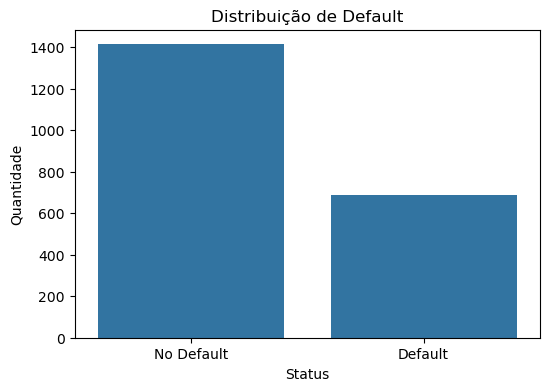

In [17]:
#DISTRIBUIÇÃO DO TARGET

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Default_Label")
plt.title("Distribuição de Default")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.savefig('distribuição_defalt.png')
plt.show()

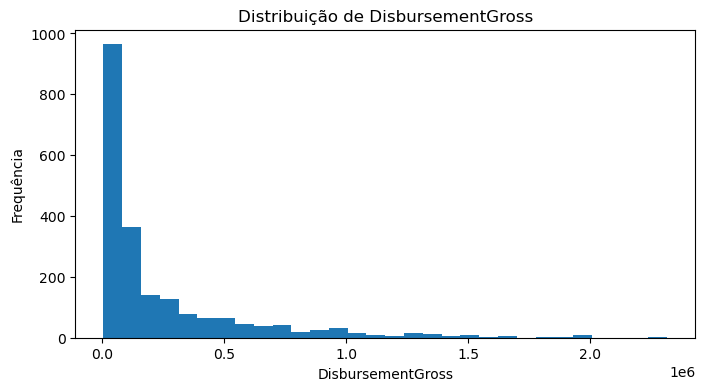

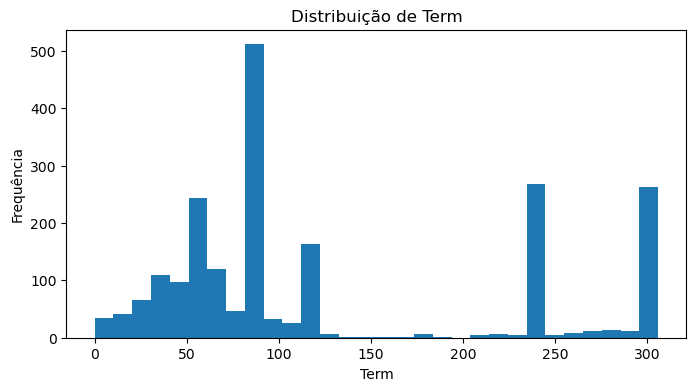

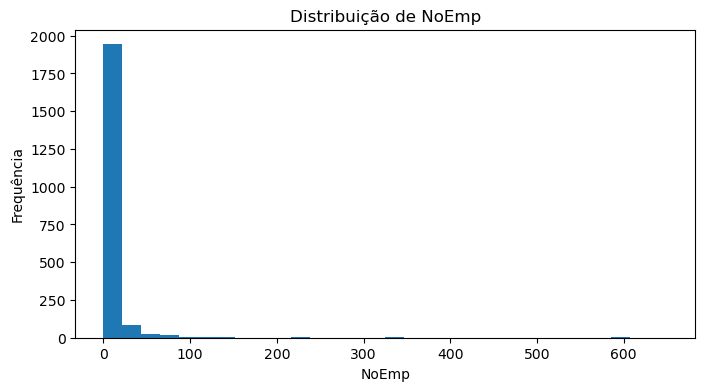

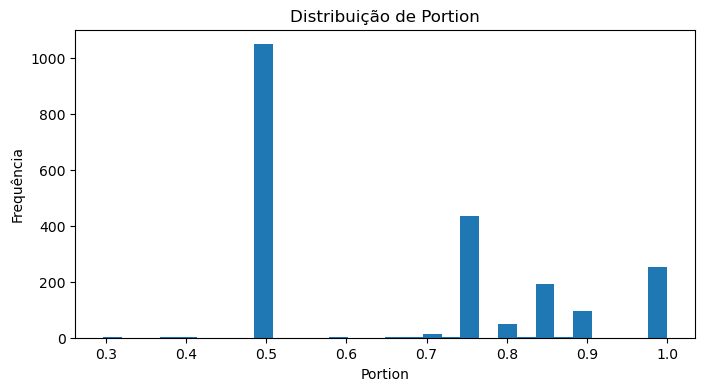

In [18]:
#DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS

num_cols = ["DisbursementGross", "Term", "NoEmp", "Portion"]

for col in num_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df_clean[col].dropna(), bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

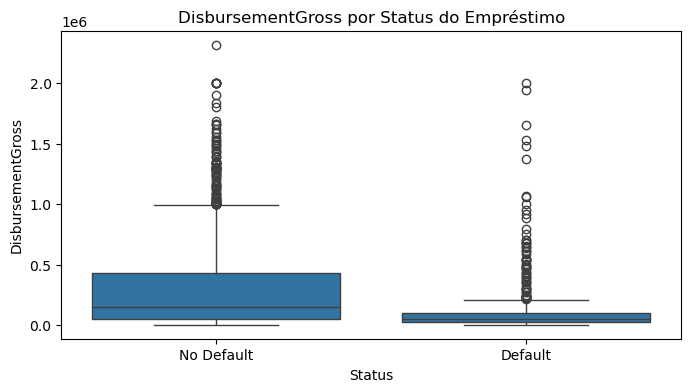

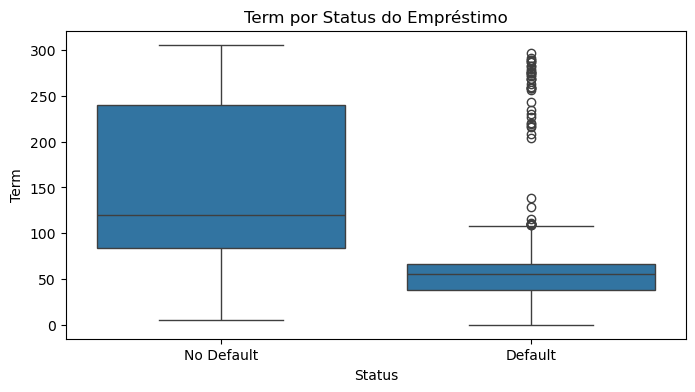

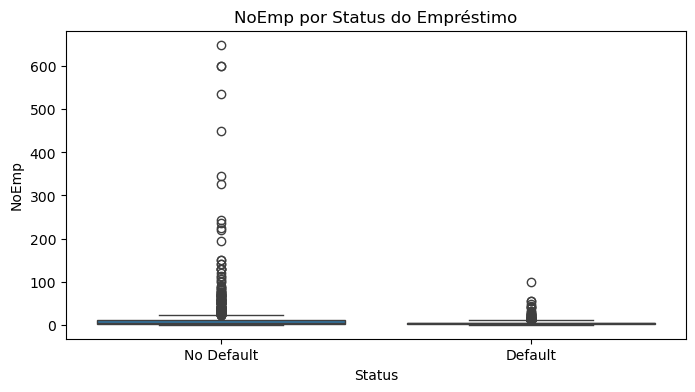

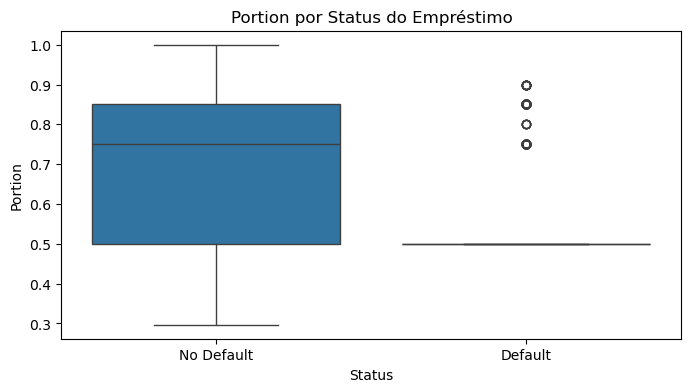

In [19]:
#BOXPLOTS POR DEFAULT

for col in ["DisbursementGross", "Term", "NoEmp", "Portion"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_clean, x="Default_Label", y=col)
    plt.title(f"{col} por Status do Empréstimo")
    plt.xlabel("Status")
    plt.ylabel(col)
    plt.show()

In [20]:
#TAXA DE INADIMPLÊNCIA POR CATEGORIA

def taxa_inadimplencia(col):
    tabela = (
        df_clean.groupby(col)["Default"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
        .rename(columns={"count": "Total", "mean": "Taxa_Inadimplencia"})
    )
    tabela["Taxa_Inadimplencia"] = tabela["Taxa_Inadimplencia"] * 100
    return tabela

display(taxa_inadimplencia("Business_Type"))
display(taxa_inadimplencia("NoEmp_Faixa"))
display(taxa_inadimplencia("Term_Faixa"))
display(taxa_inadimplencia("Disbursement_Faixa"))
display(taxa_inadimplencia("Recession_Label"))
display(taxa_inadimplencia("RevLineCr_Label"))
display(taxa_inadimplencia("LowDoc_Label"))
display(taxa_inadimplencia("UrbanRural_Label"))
display(taxa_inadimplencia("RealEstate"))


,Total,Taxa_Inadimplencia
Business_Type,,
New Business,324,34.567901
Existing Business,1773,32.374506
Unknown,2,0.000000


C:\Users\jamil\AppData\Local\Temp\ipykernel_14488\708980790.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(col)["Default"]


,Total,Taxa_Inadimplencia
NoEmp_Faixa,,
Micro,1364,38.343109
Pequena,570,25.614035
Média,140,12.142857
Grande,25,0.000000


C:\Users\jamil\AppData\Local\Temp\ipykernel_14488\708980790.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(col)["Default"]


,Total,Taxa_Inadimplencia
Term_Faixa,,
Até 5 anos,570,75.789474
5-10 anos,913,23.439211
10-15 anos,19,10.526316
Acima de 20 anos,312,8.333333
15-20 anos,282,3.191489


...

,Total,Taxa_Inadimplencia
Recession_Label,,
Yes,144,54.861111
No,1955,31.048593


,Total,Taxa_Inadimplencia
RevLineCr_Label,,
Yes,735,47.210884
No,580,34.827586
Unknown,784,17.474490


,Total,Taxa_Inadimplencia
LowDoc_Label,,
Unknown,8,62.500000
No,2050,32.926829
Yes,41,14.634146


,Total,Taxa_Inadimplencia
UrbanRural_Label,,
Rural,127,40.944882
Urban,1740,35.402299
Undefined,232,7.758621


,Total,Taxa_Inadimplencia
RealEstate,,
0,1522,43.363995
1,577,4.506066


In [21]:
#NAICS: SUBSEGMENTOS
naics_risk = (
    df_clean.groupby("NAICS")["Default"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
    .rename(columns={"count": "Total", "mean": "Taxa_Inadimplencia"})
)

naics_risk["Taxa_Inadimplencia"] = naics_risk["Taxa_Inadimplencia"] * 100
display(naics_risk.head(15))

,Total,Taxa_Inadimplencia
NAICS,,
53,2099,32.68223


In [22]:
#COMPARAÇÃO DE MÉDIAS ENTRE ADIMPLENTES E INADIMPLENTES

group_stats = df_clean.groupby("Default").agg(
    quantidade=("Default", "size"),
    media_valor=("DisbursementGross", "mean"),
    mediana_valor=("DisbursementGross", "median"),
    media_prazo=("Term", "mean"),
    mediana_prazo=("Term", "median"),
    media_funcionarios=("NoEmp", "mean"),
    mediana_funcionarios=("NoEmp", "median"),
    media_portion=("Portion", "mean")
)

display(group_stats)

,quantidade,media_valor,mediana_valor,media_prazo,mediana_prazo,media_funcionarios,mediana_funcionarios,media_portion
Default,,,,,,,,
0,1413,307133.510970,150000.0,158.577495,120.0,12.789101,4.0,0.719219
1,686,110938.854227,52400.0,62.225948,55.0,4.734694,3.0,0.572595


In [23]:
#Teste de normalidade

from scipy.stats import shapiro

num_cols = ["DisbursementGross", "Term", "NoEmp", "Portion"]

normality_results = []

for col in num_cols:
    sample = df_clean[col].dropna()

    if len(sample) > 500:
        sample = sample.sample(500, random_state=42)

    stat, p_value = shapiro(sample)
    
    normality_results.append({
        "Variável": col,
        "Estatística": stat,
        "p_value": p_value,
        "Normal?": "Sim" if p_value > 0.05 else "Não"
    })

normality_df = pd.DataFrame(normality_results)
display(normality_df)

,Variável,Estatística,p_value,Normal?
0,DisbursementGross,0.672721,6.466844e-30,Não
1,Term,0.814940,1.529650e-23,Não
2,NoEmp,0.198666,1.461768e-41,Não
3,Portion,0.787795,5.347652e-25,Não


In [24]:
#Testes para variáveis numéricas
from scipy.stats import mannwhitneyu

g0 = df_clean[df_clean["Default"] == 0]
g1 = df_clean[df_clean["Default"] == 1]

mw_results = []

for col in ["Term", "DisbursementGross", "NoEmp", "Portion"]:
    x = g0[col].dropna()
    y = g1[col].dropna()

    stat, p_value = mannwhitneyu(x, y, alternative="two-sided")
    
    mw_results.append({
        "Variável": col,
        "U_stat": stat,
        "p_value": p_value,
        "Mediana_NoDefault": x.median(),
        "Mediana_Default": y.median(),
        "Média_NoDefault": x.mean(),
        "Média_Default": y.mean(),
        "Conclusão": "Diferença significativa" if p_value <= 0.05 else "Sem diferença significativa"
    })

mw_results_df = pd.DataFrame(mw_results)
display(mw_results_df)

,Variável,U_stat,p_value,Mediana_NoDefault,Mediana_Default,Média_NoDefault,Média_Default,Conclusão
0,Term,854867.5,1.438387e-180,120.00,55.0,158.577495,62.225948,Diferença significativa
1,DisbursementGross,680454.0,4.306305e-51,150000.00,52400.0,307133.510970,110938.854227,Diferença significativa
2,NoEmp,592412.0,6.905879e-17,4.00,3.0,12.789101,4.734694,Diferença significativa
3,Portion,685917.5,5.351826e-62,0.75,0.5,0.719219,0.572595,Diferença significativa


In [25]:
#Testes para variáveis categóricas

from scipy.stats import chi2_contingency 
import numpy as np

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.to_numpy().sum() 
    r, k = contingency_table.shape
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1))) 
    
cat_cols = [
    "Business_Type",
    "Recession_Label",
    "RevLineCr_Label",
    "LowDoc_Label",
    "UrbanRural_Label",
    "RealEstate",
    "NoEmp_Faixa",
    "Term_Faixa",
    "Disbursement_Faixa"
]

chi_results = []

for col in cat_cols:
    table = pd.crosstab(df_clean[col], df_clean["Default"]) 
    chi2, p_value, dof, expected = chi2_contingency(table)
    cv = cramers_v(table)
    
    chi_results.append({
        "Variável": col,
        "Qui_Quadrado": chi2,
        "p_value": p_value,
        "Graus_de_Liberdade": dof,
        "Cramers_V": cv,
        "Conclusão": "Associação significativa" if p_value <= 0.05 else "Sem associação significativa"
    })

chi_results_df = pd.DataFrame(chi_results)
display(chi_results_df)

,Variável,Qui_Quadrado,p_value,Graus_de_Liberdade,Cramers_V,Conclusão
0,Business_Type,1.570938,4.559058e-01,2,0.027357,Sem associação significativa
1,Recession_Label,33.493479,7.150333e-09,1,0.126321,Associação significativa
2,RevLineCr_Label,154.145395,3.370954e-34,2,0.270994,Associação significativa
3,LowDoc_Label,9.358920,9.284028e-03,2,0.066774,Associação significativa
4,UrbanRural_Label,75.296554,4.462323e-17,2,0.189401,Associação significativa
5,RealEstate,285.377996,5.054481e-64,1,0.368726,Associação significativa
6,NoEmp_Faixa,71.792992,1.763025e-15,3,0.184942,Associação significativa
7,Term_Faixa,717.757771,4.977792e-154,4,0.585185,Associação significativa
8,Disbursement_Faixa,259.583114,5.533308e-56,3,0.351667,Associação significativa


In [26]:
df_score = df_clean.copy()

In [27]:
#ATRIBUIÇÃO DE PONTOS POR REGRA

# Prazo
term_score_map = {
    "Até 5 anos": 3,
    "5-10 anos": 2,
    "10-15 anos": 1,
    "15-20 anos": 0,
    "Acima de 20 anos": 0
}

# Valor desembolsado
value_score_map = {
    "Baixo": 3,
    "Médio-Baixo": 2,
    "Médio-Alto": 1,
    "Alto": 0
}

# Porte da empresa
size_score_map = {
    "Micro": 3,
    "Pequena": 2,
    "Média": 1,
    "Grande": 0
}

# Recessão
recession_score_map = {
    "Yes": 2,
    "No": 0
}

# RealEstate
realestate_score_map = {
    0: 2,
    1: 0
}

# Linha de crédito rotativa
revline_score_map = {
    "Yes": 2,
    "No": 1,
    "Unknown": 0
}

df_score["Score_Term"] = df_score["Term_Faixa"].map(term_score_map)
df_score["Score_Value"] = df_score["Disbursement_Faixa"].map(value_score_map)
df_score["Score_Size"] = df_score["NoEmp_Faixa"].map(size_score_map)
df_score["Score_Recession"] = df_score["Recession_Label"].map(recession_score_map)
df_score["Score_RealEstate"] = df_score["RealEstate"].map(realestate_score_map)
df_score["Score_RevLineCr"] = df_score["RevLineCr_Label"].map(revline_score_map)

display(df_score[[
    "Term_Faixa", "Score_Term",
    "Disbursement_Faixa", "Score_Value",
    "NoEmp_Faixa", "Score_Size",
    "Recession_Label", "Score_Recession",
    "RealEstate", "Score_RealEstate",
    "RevLineCr_Label", "Score_RevLineCr"
]].head())

,Term_Faixa,Score_Term,Disbursement_Faixa,Score_Value,NoEmp_Faixa,Score_Size,Recession_Label,Score_Recession,RealEstate,Score_RealEstate,RevLineCr_Label,Score_RevLineCr
0,Até 5 anos,3.0,Baixo,3,Micro,3,No,0,0,2,Yes,2
1,Até 5 anos,3.0,Baixo,3,Micro,3,Yes,2,0,2,Yes,2
2,Até 5 anos,3.0,Baixo,3,Pequena,2,No,0,0,2,Yes,2
3,Até 5 anos,3.0,Médio-Baixo,2,Pequena,2,No,0,0,2,Yes,2
4,15-20 anos,0.0,Alto,0,Média,1,No,0,1,0,Unknown,0


In [28]:
#SCORE FINAL

score_cols = [
    "Score_Term",
    "Score_Value",
    "Score_Size",
    "Score_Recession",
    "Score_RealEstate",
    "Score_RevLineCr"
]

df_score["Risk_Score"] = df_score[score_cols].sum(axis=1)

display(df_score[["Risk_Score"]].describe())

,Risk_Score
count,2099.000000
mean,8.347785
std,3.841108
min,0.000000
25%,4.000000
50%,10.000000
75%,11.000000
max,15.000000


In [29]:
#CRIAÇÃO DAS FAIXAS DE RISCO

df_score["Risk_Level"] = pd.cut(
    df_score["Risk_Score"],
    bins=[-1, 4, 8, 15],
    labels=["Baixo Risco", "Médio Risco", "Alto Risco"]
)

display(df_score[["Risk_Score", "Risk_Level"]].head())

,Risk_Score,Risk_Level
0,13.0,Alto Risco
1,15.0,Alto Risco
2,12.0,Alto Risco
3,11.0,Alto Risco
4,1.0,Baixo Risco


In [30]:
#DISTRIBUIÇÃO DOS NÍVEIS DE RISCO
risk_dist = df_score["Risk_Level"].value_counts(dropna=False)
display(risk_dist)

Risk_Level
Alto Risco     1282
Baixo Risco     549
Médio Risco     268
Name: count, dtype: int64

In [31]:
#TAXA DE INADIMPLÊNCIA POR NÍVEL DE RISCO

risk_default = (
    df_score.groupby("Risk_Level")["Default"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Total", "mean": "Taxa_Inadimplencia"})
    .sort_values("Taxa_Inadimplencia", ascending=False)
)

risk_default["Taxa_Inadimplencia"] = risk_default["Taxa_Inadimplencia"] * 100
display(risk_default)

C:\Users\jamil\AppData\Local\Temp\ipykernel_14488\3193464206.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_score.groupby("Risk_Level")["Default"]


,Total,Taxa_Inadimplencia
Risk_Level,,
Alto Risco,1282,48.205928
Médio Risco,268,14.925373
Baixo Risco,549,5.100182


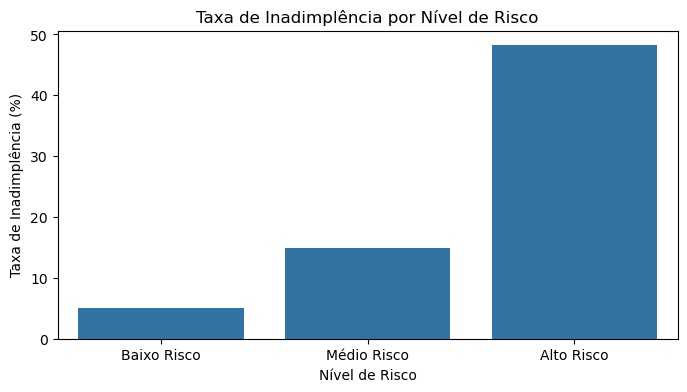

In [32]:
#VISUALIZAÇÃO DA TAXA DE INADIMPLÊNCIA POR SCORE

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(
    data=risk_default.reset_index(),
    x="Risk_Level",
    y="Taxa_Inadimplencia"
)
plt.title("Taxa de Inadimplência por Nível de Risco")
plt.xlabel("Nível de Risco")
plt.ylabel("Taxa de Inadimplência (%)")
plt.show()

In [33]:
#INSPEÇÃO DOS PERFIS MAIS ARRISCADOS

high_risk_profiles = df_score[df_score["Risk_Level"] == "Alto Risco"]

display(
    high_risk_profiles[[
        "Default_Label",
        "Term_Faixa",
        "Disbursement_Faixa",
        "NoEmp_Faixa",
        "Recession_Label",
        "RealEstate",
        "RevLineCr_Label",
        "Risk_Score",
        "Risk_Level"
    ]].head(10)
)

,Default_Label,Term_Faixa,Disbursement_Faixa,NoEmp_Faixa,Recession_Label,RealEstate,RevLineCr_Label,Risk_Score,Risk_Level
0,No Default,Até 5 anos,Baixo,Micro,No,0,Yes,13.0,Alto Risco
1,No Default,Até 5 anos,Baixo,Micro,Yes,0,Yes,15.0,Alto Risco
2,No Default,Até 5 anos,Baixo,Pequena,No,0,Yes,12.0,Alto Risco
3,No Default,Até 5 anos,Médio-Baixo,Pequena,No,0,Yes,11.0,Alto Risco
5,No Default,5-10 anos,Médio-Baixo,Micro,No,0,Yes,11.0,Alto Risco
7,No Default,5-10 anos,Médio-Baixo,Micro,No,0,Yes,11.0,Alto Risco
8,Default,Até 5 anos,Médio-Baixo,Micro,No,0,No,11.0,Alto Risco
9,No Default,5-10 anos,Baixo,Micro,No,0,Yes,12.0,Alto Risco
10,Default,5-10 anos,Médio-Baixo,Pequena,No,0,Yes,10.0,Alto Risco
11,No Default,5-10 anos,Baixo,Micro,No,0,Yes,12.0,Alto Risco


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df_dashboard = df_score.copy()

#KPIs
total_loans = len(df_dashboard)
default_rate = df_dashboard["Default"].mean() * 100
total_disbursement = df_dashboard["DisbursementGross"].sum()
avg_term = df_dashboard["Term"].mean()
avg_disbursement = df_dashboard["DisbursementGross"].mean()
avg_risk_score = df_dashboard["Risk_Score"].mean()

print("===== KPIs EXECUTIVOS =====")
print(f"Total de empréstimos: {total_loans}")
print(f"Taxa de inadimplência: {default_rate:.2f}%")
print(f"Valor total desembolsado: {total_disbursement:,.2f}")
print(f"Prazo médio: {avg_term:.2f} meses")
print(f"Valor médio desembolsado: {avg_disbursement:,.2f}")
print(f"Score médio de risco: {avg_risk_score:.2f}")

===== KPIs EXECUTIVOS =====
Total de empréstimos: 2099
Taxa de inadimplência: 32.68%
Valor total desembolsado: 510,083,705.00
Prazo médio: 127.09 meses
Valor médio desembolsado: 243,012.72
Score médio de risco: 8.35


In [35]:
#FUNÇÃO AUXILIAR
def risk_table(col):
    tabela = (
        df_dashboard.groupby(col)["Default"]
        .agg(["count", "mean"])
        .rename(columns={"count": "Total", "mean": "Taxa_Inadimplencia"})
        .sort_values("Taxa_Inadimplencia", ascending=False)
    )
    tabela["Taxa_Inadimplencia"] = tabela["Taxa_Inadimplencia"] * 100
    return tabela

In [36]:
#TABELAS DE APOIO
size_risk = risk_table("NoEmp_Faixa")
term_risk = risk_table("Term_Faixa")
value_risk = risk_table("Disbursement_Faixa")
score_risk = risk_table("Risk_Level")
recession_risk = risk_table("Recession_Label")
realestate_risk = risk_table("RealEstate")
revline_risk = risk_table("RevLineCr_Label")
urban_risk = risk_table("UrbanRural_Label")

display(size_risk)
display(term_risk)
display(value_risk)
display(score_risk)
display(recession_risk)

C:\Users\jamil\AppData\Local\Temp\ipykernel_14488\1920704440.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dashboard.groupby(col)["Default"]


,Total,Taxa_Inadimplencia
NoEmp_Faixa,,
Micro,1364,38.343109
Pequena,570,25.614035
Média,140,12.142857
Grande,25,0.000000


,Total,Taxa_Inadimplencia
Term_Faixa,,
Até 5 anos,570,75.789474
5-10 anos,913,23.439211
10-15 anos,19,10.526316
Acima de 20 anos,312,8.333333
15-20 anos,282,3.191489


,Total,Taxa_Inadimplencia
Disbursement_Faixa,,
Médio-Baixo,584,48.116438
Baixo,525,47.047619
Médio-Alto,470,23.191489
Alto,520,9.423077


,Total,Taxa_Inadimplencia
Risk_Level,,
Alto Risco,1282,48.205928
Médio Risco,268,14.925373
Baixo Risco,549,5.100182


,Total,Taxa_Inadimplencia
Recession_Label,,
Yes,144,54.861111
No,1955,31.048593


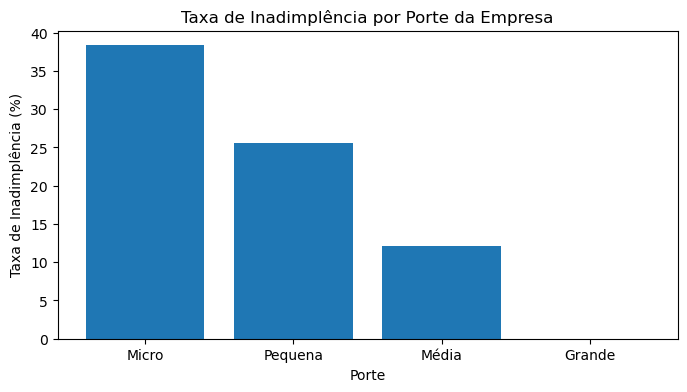

In [37]:
#GRÁFICO: DEFAULT POR PORTE
plt.figure(figsize=(8,4))
plt.bar(size_risk.index.astype(str), size_risk["Taxa_Inadimplencia"])
plt.title("Taxa de Inadimplência por Porte da Empresa")
plt.xlabel("Porte")
plt.ylabel("Taxa de Inadimplência (%)")
plt.savefig('inadimplencia_por_porte.png')
plt.show()

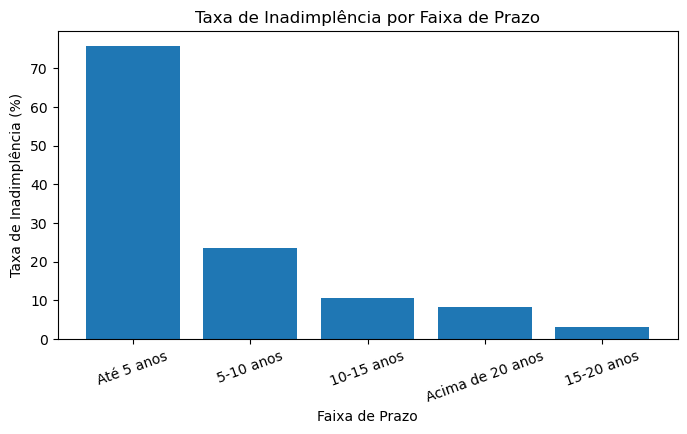

In [38]:
#GRÁFICO: DEFAULT POR PRAZO

plt.figure(figsize=(8,4))
plt.bar(term_risk.index.astype(str), term_risk["Taxa_Inadimplencia"])
plt.title("Taxa de Inadimplência por Faixa de Prazo")
plt.xlabel("Faixa de Prazo")
plt.ylabel("Taxa de Inadimplência (%)")
plt.xticks(rotation=20)
plt.savefig('inadimplencia_f_prazo.png')
plt.show()

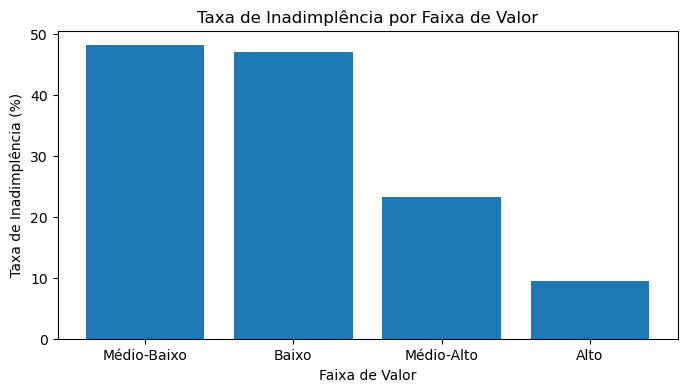

In [39]:
#GRÁFICO: DEFAULT POR VALOR
plt.figure(figsize=(8,4))
plt.bar(value_risk.index.astype(str), value_risk["Taxa_Inadimplencia"])
plt.title("Taxa de Inadimplência por Faixa de Valor")
plt.xlabel("Faixa de Valor")
plt.ylabel("Taxa de Inadimplência (%)")
plt.savefig('inadimplencia_f_valor.png')
plt.show()

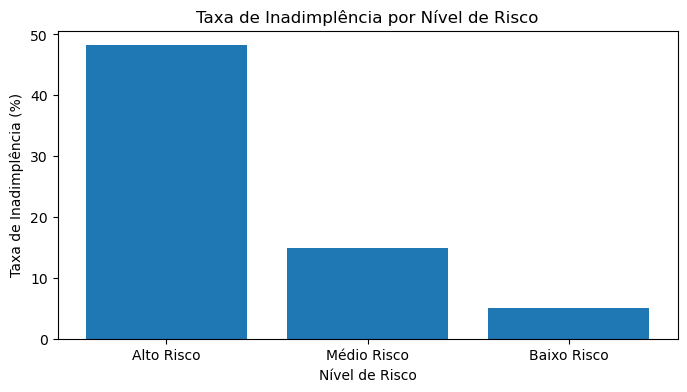

In [40]:
#GRÁFICO: DEFAULT POR NÍVEL DE RISCO
plt.figure(figsize=(8,4))
plt.bar(score_risk.index.astype(str), score_risk["Taxa_Inadimplencia"])
plt.title("Taxa de Inadimplência por Nível de Risco")
plt.xlabel("Nível de Risco")
plt.ylabel("Taxa de Inadimplência (%)")
plt.savefig('nivel_risco.png')
plt.show()

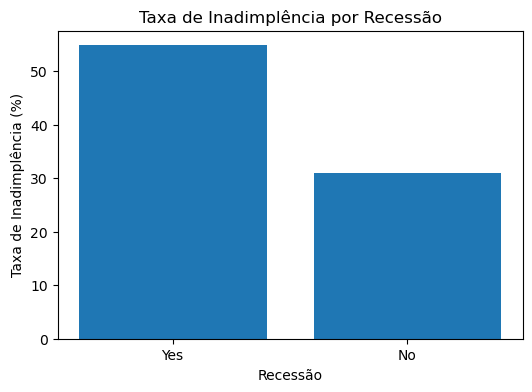

In [41]:
#GRÁFICO: DEFAULT POR RECESSÃO
plt.figure(figsize=(6,4))
plt.bar(recession_risk.index.astype(str), recession_risk["Taxa_Inadimplencia"])
plt.title("Taxa de Inadimplência por Recessão")
plt.xlabel("Recessão")
plt.ylabel("Taxa de Inadimplência (%)")
plt.savefig('inadimplencia_recessao.png')
plt.show()

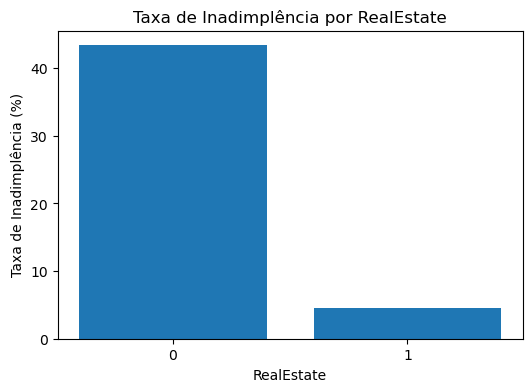

In [42]:
#GRÁFICO: DEFAULT POR REALESTATE
plt.figure(figsize=(6,4))
plt.bar(realestate_risk.index.astype(str), realestate_risk["Taxa_Inadimplencia"])
plt.title("Taxa de Inadimplência por RealEstate")
plt.xlabel("RealEstate")
plt.ylabel("Taxa de Inadimplência (%)")
plt.show()

In [43]:
#TOP NAICS MAIS ARRISCADOS
naics_risk = (
    df_dashboard.groupby("NAICS")["Default"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Total", "mean": "Taxa_Inadimplencia"})
)

naics_risk["Taxa_Inadimplencia"] = naics_risk["Taxa_Inadimplencia"] * 100
naics_risk = naics_risk[naics_risk["Total"] >= 20].sort_values("Taxa_Inadimplencia", ascending=False)

display(naics_risk.head(10))

,Total,Taxa_Inadimplencia
NAICS,,
53,2099,32.68223


In [44]:
#RESUMO FINAL
summary_table = pd.DataFrame({
    "KPI": [
        "Total de empréstimos",
        "Taxa de inadimplência (%)",
        "Valor total desembolsado",
        "Prazo médio",
        "Valor médio desembolsado",
        "Score médio de risco"
    ],
    "Valor": [
        total_loans,
        round(default_rate, 2),
        round(total_disbursement, 2),
        round(avg_term, 2),
        round(avg_disbursement, 2),
        round(avg_risk_score, 2)
    ]
})

display(summary_table)

,KPI,Valor
0,Total de empréstimos,2.099000e+03
1,Taxa de inadimplência (%),3.268000e+01
2,Valor total desembolsado,5.100837e+08
3,Prazo médio,1.270900e+02
4,Valor médio desembolsado,2.430127e+05
5,Score médio de risco,8.350000e+00
